In [18]:
import kagglehub
import os 
# Download latest version
smap_path = kagglehub.dataset_download("team-ai/spam-text-message-classification")

print("Path to dataset files:", smap_path)

files = os.listdir(smap_path)

file_path = smap_path+ '/'+ files[0]

Path to dataset files: /Users/rafael/.cache/kagglehub/datasets/team-ai/spam-text-message-classification/versions/1


In [19]:
# Importing necessary libraries
import numpy as np        # For numerical operations
import pandas as pd       # For data manipulation and analysis
import matplotlib.pyplot as plt  # For data visualization
%matplotlib inline

# Importing WordCloud for text visualization
from wordcloud import WordCloud

# Importing NLTK for natural language processing
import nltk
from nltk.corpus import stopwords    # For stopwords


# Downloading NLTK data
nltk.download('stopwords')   # Downloading stopwords data
nltk.download('punkt')       # Downloading tokenizer data


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rafael/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/rafael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
df = pd.read_csv(file_path)

In [21]:
styled_df = df.head()
styled_df = styled_df.style.set_table_styles([
    {"selector": "th", "props": [("color", 'black'), ("background-color", "#FF00CC")]}
])
styled_df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 542.2 KB


In [23]:
styled_df = df.head(5).style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [24]:
  # Rename the columns name
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)

In [26]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

KeyError: 'target'

In [ ]:
styled_df = df.head().style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])


,target,text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives around here though"


In [ ]:
#checking missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [ ]:
#check duplicate values
df.duplicated().sum()

403

In [ ]:
#remove Duplicate
df = df.drop_duplicates(keep = 'first')

In [ ]:
df.shape

(5169, 2)

In [ ]:
values = df['target'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('percentage of 0 :' ,percentage_0)
print('percentage of 1 :' ,percentage_1)

percentage of 0 : 87.3669955503966
percentage of 1 : 12.633004449603405


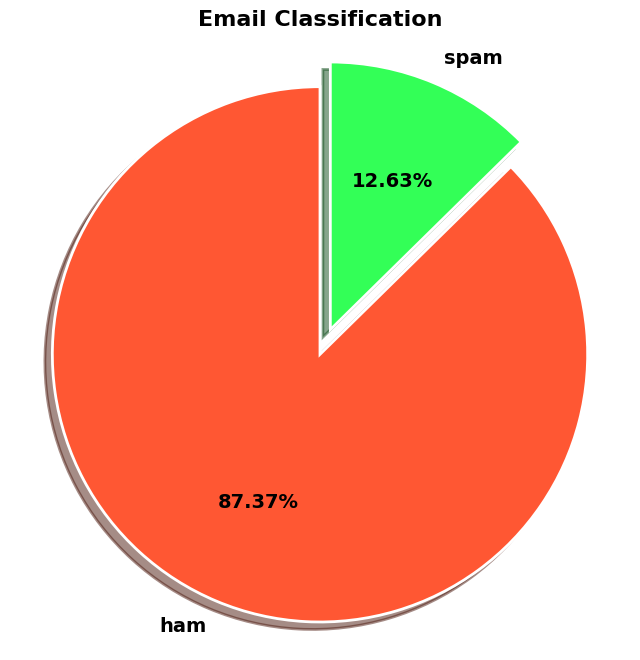

In [ ]:
import matplotlib.pyplot as plt

# Sample data
# values = [75, 25]  # Example values for 'ham' and 'spam'

# Define custom colors
colors = ['#FF5733', '#33FF57']

# Define the explode parameter to create a gap between slices
explode = (0, 0.1)  # Explode the second slice (spam) by 10%

# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

# Create the pie chart with custom colors, labels, explode parameter, and shadow
wedges, texts, autotexts = ax.pie(
    values, labels=['ham', 'spam'],
    autopct='%0.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    explode=explode,  # Apply the explode parameter
    shadow=True  # Add shadow
)

# Customize text properties
for text, autotext in zip(texts, autotexts):
    text.set(size=14, weight='bold')
    autotext.set(size=14, weight='bold')

# Add a title
ax.set_title('Email Classification', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')
# Show the pie chart
plt.show()

As you see to the graph the percentage of ham is too high (87.37%) as compare to spam messages percentage. so the data is imbalance

In [ ]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.286129,1.961308
std,58.236293,13.226400,1.432583
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,219.000000,38.000000


In [ ]:
#ham
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,16.957484,1.815545
std,56.358207,13.394052,1.364098
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,219.000000,38.000000


In [ ]:
#spam
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.474732,2.969372
std,30.137753,6.893007,1.488910
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,44.000000,9.000000


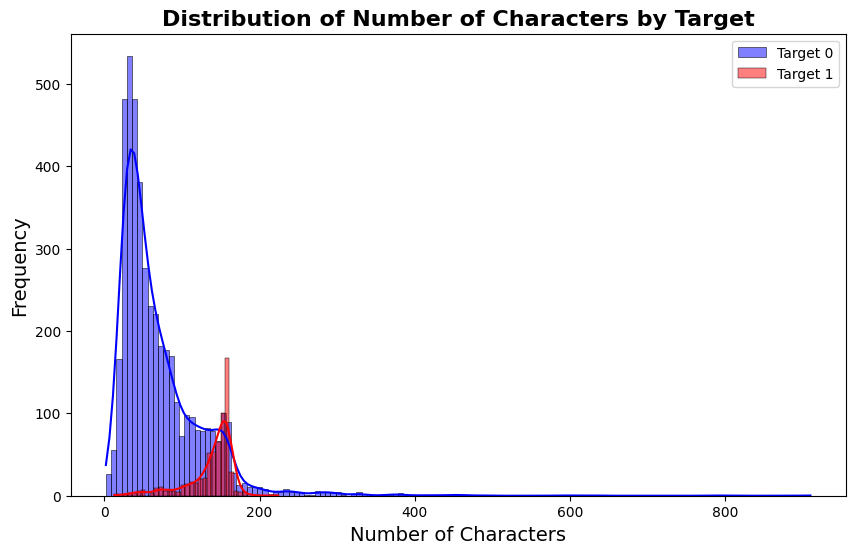

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Characters by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


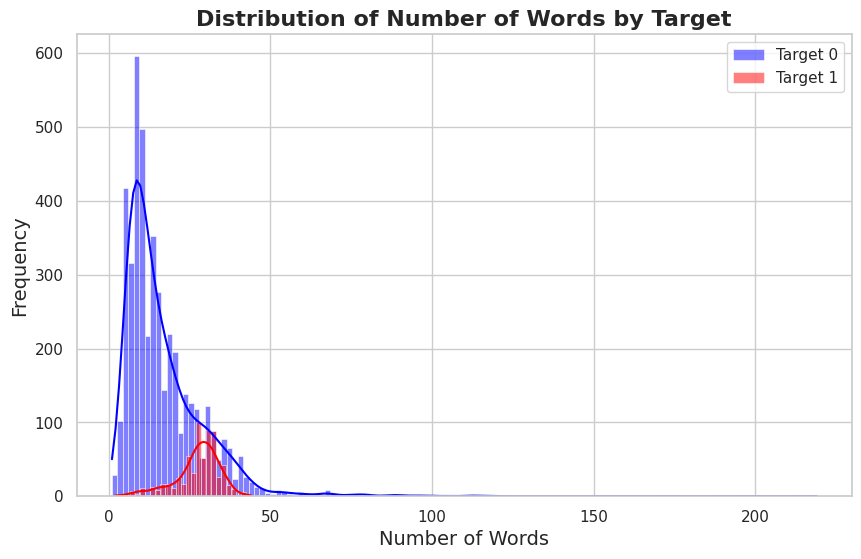

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


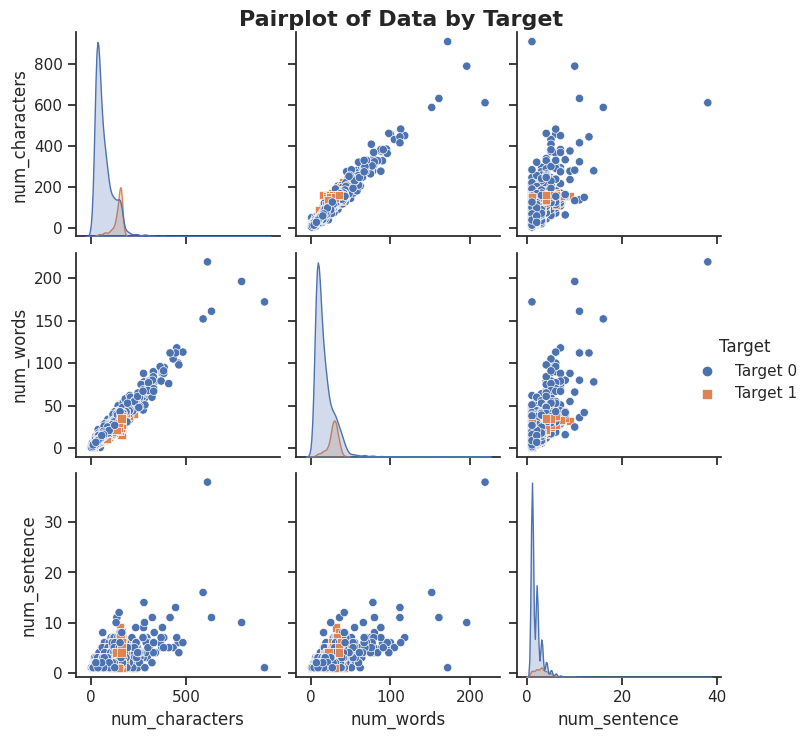

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot with custom styling
sns.set(style='ticks', color_codes=True)
g = sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s"])

# Set a title for the pairplot
g.fig.suptitle("Pairplot of Data by Target", fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)  # Adjust the position of the title

# Customize the legend
g._legend.set_title('Target')
for t, l in zip(g._legend.texts, ["Target 0", "Target 1"]):
    t.set_text(l)

# Show the pairplot
plt.show()


In [ ]:
df[['target','num_characters', 'num_words', 'num_sentence']].corr()

,target,num_characters,num_words,num_sentence
target,1.000000,0.384717,0.264198,0.267602
num_characters,0.384717,1.000000,0.965307,0.626118
num_words,0.264198,0.965307,1.000000,0.683561
num_sentence,0.267602,0.626118,0.683561,1.000000


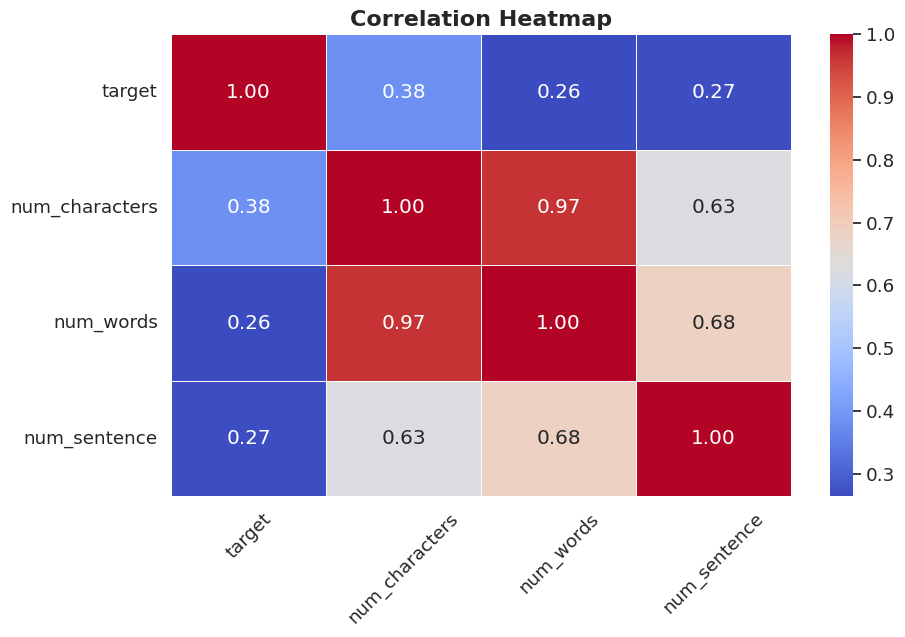

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns for the correlation matrix
correlation_matrix = df[['target', 'num_characters', 'num_words', 'num_sentence']].corr()

# Create a heatmap with custom styling
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)  # Adjust font scale for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

# Set a title for the heatmap
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the heatmap
plt.show()


In [ ]:
# Importing the Porter Stemmer for text stemming
from nltk.stem.porter import PorterStemmer

# Importing the string module for handling special characters
import string

# Creating an instance of the Porter Stemmer
ps = PorterStemmer()

# Lowercase transformation and text preprocessing function
def transform_text(text):
    # Transform the text to lowercase
    text = text.lower()
    
    # Tokenization using NLTK
    text = nltk.word_tokenize(text)
    
    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    # Removing stop words and punctuation
    text = y[:]
    y.clear()
    
    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
        
    # Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    # Join the processed tokens back into a single string
    return " ".join(y)


In [ ]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point avail bugi n great world la e buffet cine got amor wat'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
styled_df = df.head(5).style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FF00CC"), ('font-weight', 'bold')]}
])


,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,23,2,go jurong point avail bugi n great world la e buffet cine got amor wat
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155,37,2,free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,15,1,nah think goe usf live around though


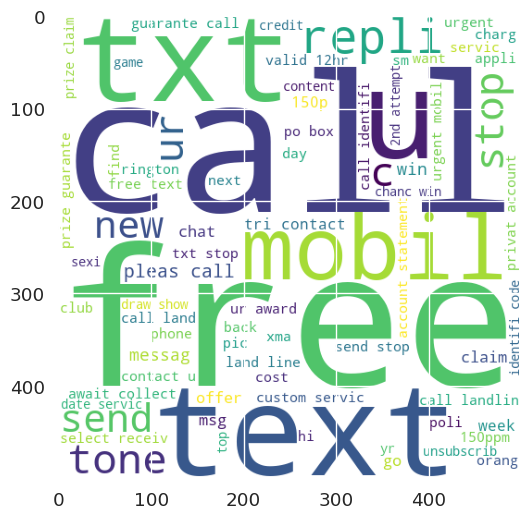

In [ ]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

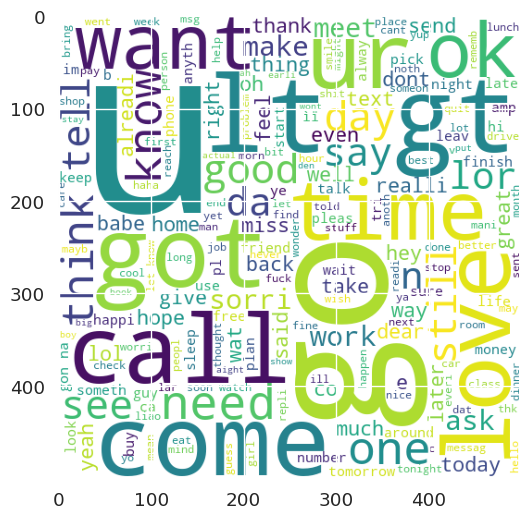

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)
plt.show()

In [ ]:
spam_carpos = []
for sentence in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentence.split():
        spam_carpos.append(word)

In [ ]:
from collections import Counter
filter_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

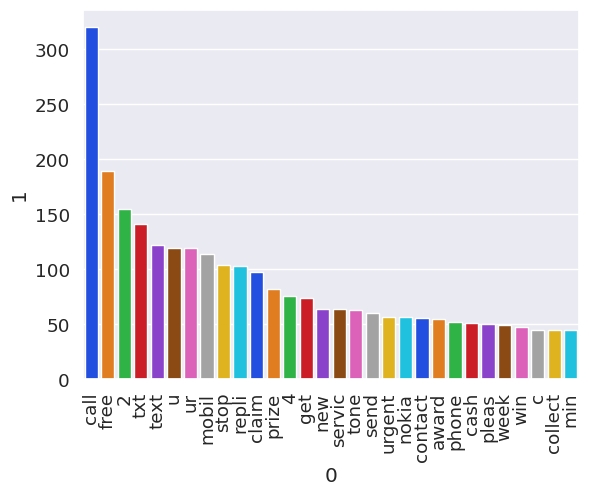

In [ ]:
sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
ham_carpos = []
for sentence in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentence.split():
        ham_carpos.append(word)

In [ ]:
filter_ham_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

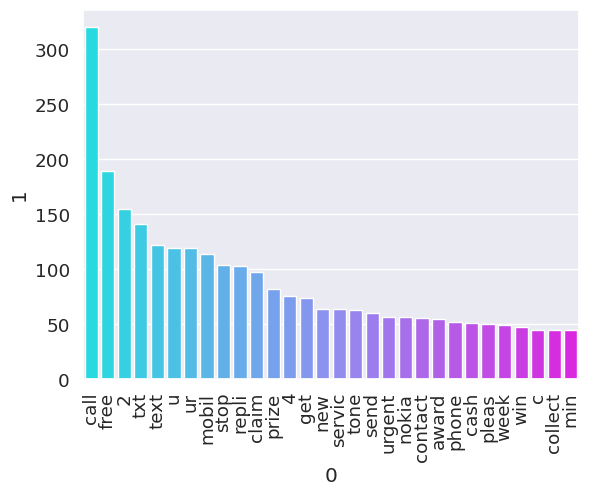

In [ ]:
sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfid = TfidfVectorizer(max_features = 3000)

In [ ]:
X = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 2)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)    
xgb  = XGBClassifier(n_estimators = 50, random_state = 2)


    

In [ ]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
    
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score
def train_classifier(clfs, X_train, y_train, X_test, y_test):
    clfs.fit(X_train,y_train)
    y_pred = clfs.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy , precision

In [ ]:
accuracy_scores = []
precision_scores = []
for name , clfs in clfs.items():
    current_accuracy, current_precision = train_classifier(clfs, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    


For:  SVC
Accuracy:  0.9748549323017408
Precision:  0.9666666666666667

For:  KNN
Accuracy:  0.9052224371373307
Precision:  1.0

For:  NB
Accuracy:  0.9729206963249516
Precision:  1.0

For:  DT
Accuracy:  0.9284332688588007
Precision:  0.826530612244898

For:  LR
Accuracy:  0.9574468085106383
Precision:  0.9519230769230769

For:  RF
Accuracy:  0.971953578336557
Precision:  0.9739130434782609

For:  Adaboost
Accuracy:  0.9642166344294004
Precision:  0.9316239316239316

For:  Bgc
Accuracy:  0.9545454545454546
Precision:  0.8527131782945736

For:  ETC
Accuracy:  0.9777562862669246
Precision:  0.9831932773109243

For:  GBDT
Accuracy:  0.9487427466150871
Precision:  0.9292929292929293

For:  xgb
Accuracy:  0.9690522243713733
Precision:  0.9416666666666667



For:  SVC
Accuracy:  0.9748549323017408
Precision:  0.9666666666666667

For:  KNN
Accuracy:  0.9052224371373307
Precision:  1.0

For:  NB
Accuracy:  0.9729206963249516
Precision:  1.0

For:  DT
Accuracy:  0.9284332688588007
Precision:  0.826530612244898

For:  LR
Accuracy:  0.9574468085106383
Precision:  0.9519230769230769

For:  RF
Accuracy:  0.971953578336557
Precision:  0.9739130434782609

For:  Adaboost
Accuracy:  0.9642166344294004
Precision:  0.9316239316239316

For:  Bgc
Accuracy:  0.9545454545454546
Precision:  0.8527131782945736

For:  ETC
Accuracy:  0.9777562862669246
Precision:  0.9831932773109243

For:  GBDT
Accuracy:  0.9487427466150871
Precision:  0.9292929292929293

For:  xgb
Accuracy:  0.9690522243713733
Precision:  0.9416666666666667

MODEL PERFORMANCE SUMMARY
   Model  Accuracy  Precision
     ETC  0.977756   0.983193
     SVC  0.974855   0.966667
      NB  0.972921   1.000000
      RF  0.971954   0.973913
     xgb  0.969052   0.941667
Adaboost  0.964217   0.931624
 

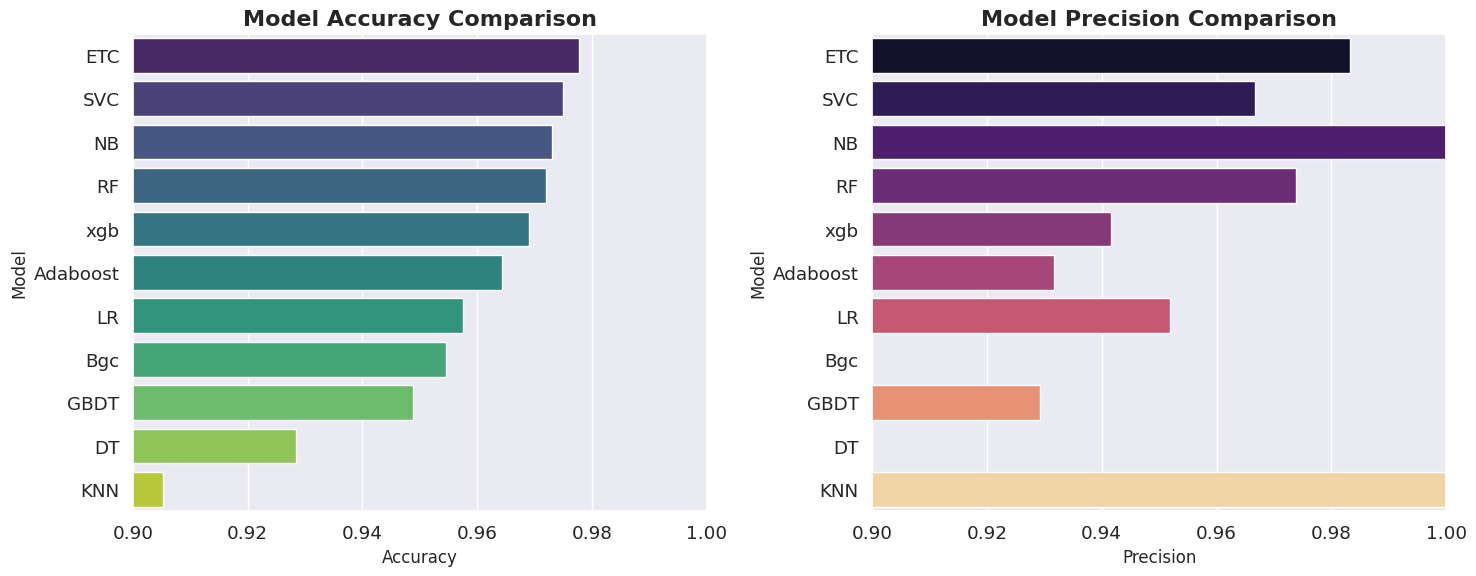


TOP 3 MODELS BY ACCURACY
Model  Accuracy  Precision
  ETC  0.977756   0.983193
  SVC  0.974855   0.966667
   NB  0.972921   1.000000

Creating ensemble with: ETC, SVC, NB

Training ensemble model...

ENSEMBLE MODEL PERFORMANCE
Accuracy:  0.9797
Precision: 0.9756

FINAL COMPARISON (Including Ensemble)
           Model  Accuracy  Precision
Ensemble (Top 3)  0.979691   0.975610
             ETC  0.977756   0.983193
             SVC  0.974855   0.966667
              NB  0.972921   1.000000
              RF  0.971954   0.973913
             xgb  0.969052   0.941667
        Adaboost  0.964217   0.931624
              LR  0.957447   0.951923
             Bgc  0.954545   0.852713
            GBDT  0.948743   0.929293
              DT  0.928433   0.826531
             KNN  0.905222   1.000000


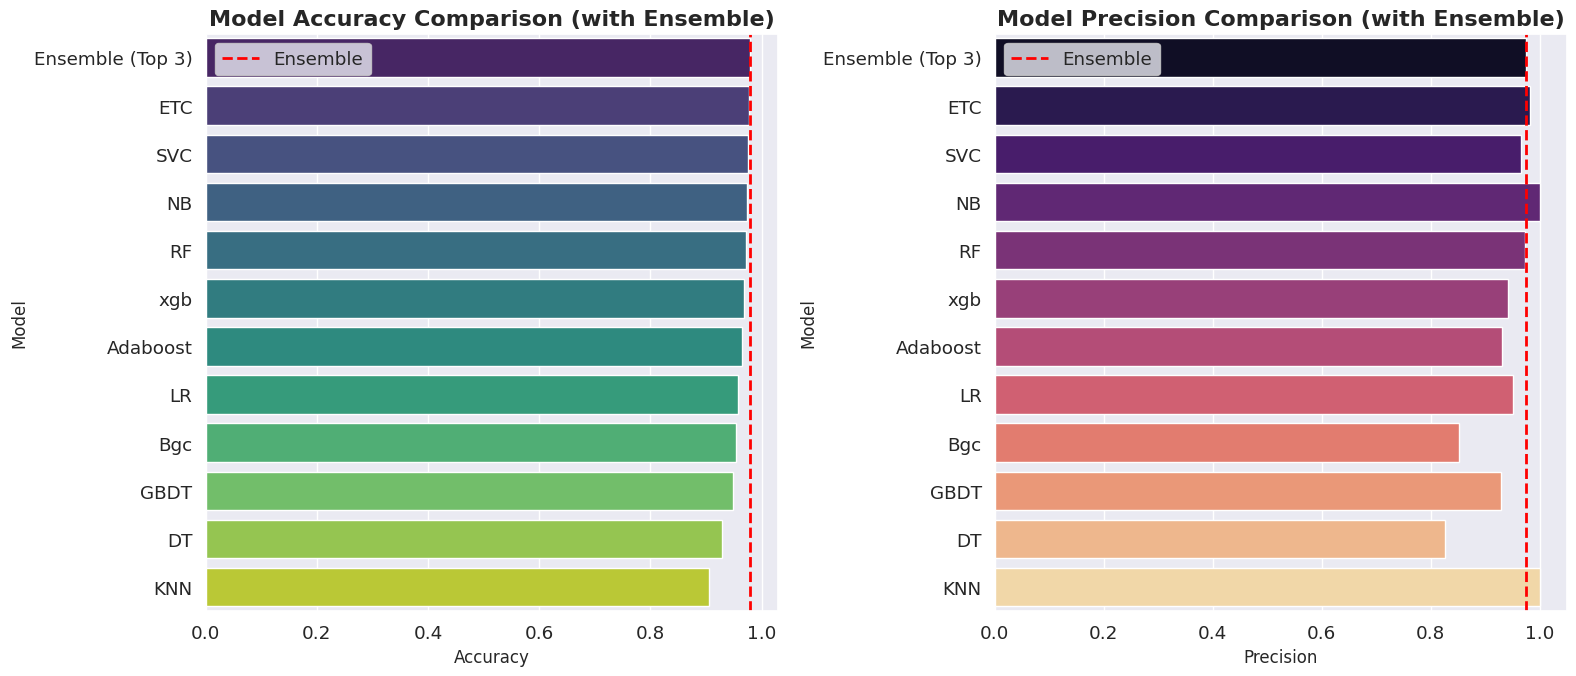

In [ ]:
# First, recreate the classifiers dictionary (it was overwritten in your previous loop)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Recreate all classifier instances
svc = SVC(kernel="sigmoid", gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

# Recreate the dictionary
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

# Train all classifiers and collect scores
accuracy_scores = []
precision_scores = []
model_names = []

# Use 'clf' instead of 'clfs' to avoid overwriting the dictionary
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    
    model_names.append(name)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

# Create a performance DataFrame for better visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Sort by accuracy to identify top 3 models
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)
print(performance_df.to_string(index=False))

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
sns.barplot(data=performance_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].set_xlim([0.9, 1.0])  # Adjust based on your scores

# Precision comparison
sns.barplot(data=performance_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].set_xlim([0.9, 1.0])  # Adjust based on your scores

plt.tight_layout()
plt.show()

# Display top 3 models
print("\n" + "="*50)
print("TOP 3 MODELS BY ACCURACY")
print("="*50)
print(performance_df.head(3).to_string(index=False))

# Create an ensemble of the top 3 models
from sklearn.ensemble import VotingClassifier

# Get the top 3 model names
top_3_models = performance_df.head(3)['Model'].tolist()
print("\n" + "="*50)
print(f"Creating ensemble with: {', '.join(top_3_models)}")
print("="*50)

# Recreate fresh instances of the top 3 models for the ensemble
top_3_classifiers = []
for model_name in top_3_models:
    if model_name == 'SVC':
        top_3_classifiers.append(('SVC', SVC(kernel="sigmoid", gamma=1.0, probability=True)))
    elif model_name == 'KNN':
        top_3_classifiers.append(('KNN', KNeighborsClassifier()))
    elif model_name == 'NB':
        top_3_classifiers.append(('NB', MultinomialNB()))
    elif model_name == 'DT':
        top_3_classifiers.append(('DT', DecisionTreeClassifier(max_depth=5)))
    elif model_name == 'LR':
        top_3_classifiers.append(('LR', LogisticRegression(solver='liblinear', penalty='l1')))
    elif model_name == 'RF':
        top_3_classifiers.append(('RF', RandomForestClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Adaboost':
        top_3_classifiers.append(('Adaboost', AdaBoostClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Bgc':
        top_3_classifiers.append(('Bgc', BaggingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'ETC':
        top_3_classifiers.append(('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'GBDT':
        top_3_classifiers.append(('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'xgb':
        top_3_classifiers.append(('xgb', XGBClassifier(n_estimators=50, random_state=2)))

# Create voting ensemble (soft voting for probability-based voting)
ensemble = VotingClassifier(estimators=top_3_classifiers, voting='soft')

# Train the ensemble
print("\nTraining ensemble model...")
ensemble.fit(X_train, y_train)

# Evaluate the ensemble
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)

print("\n" + "="*50)
print("ENSEMBLE MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")

# Compare ensemble with individual models
comparison_df = pd.DataFrame({
    'Model': model_names + ['Ensemble (Top 3)'],
    'Accuracy': accuracy_scores + [ensemble_accuracy],
    'Precision': precision_scores + [ensemble_precision]
})
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("FINAL COMPARISON (Including Ensemble)")
print("="*50)
print(comparison_df.to_string(index=False))

# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy comparison
sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].axvline(x=ensemble_accuracy, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[0].legend()

# Precision comparison
sns.barplot(data=comparison_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].axvline(x=ensemble_precision, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[1].legend()

plt.tight_layout()
plt.show()


For:  SVC
Accuracy:  0.9748549323017408
Precision:  0.9666666666666667

For:  KNN
Accuracy:  0.9052224371373307
Precision:  1.0

For:  NB
Accuracy:  0.9729206963249516
Precision:  1.0

For:  DT
Accuracy:  0.9342359767891683
Precision:  0.85

For:  LR
Accuracy:  0.9574468085106383
Precision:  0.9519230769230769

For:  RF
Accuracy:  0.971953578336557
Precision:  0.9739130434782609

For:  Adaboost
Accuracy:  0.9642166344294004
Precision:  0.9316239316239316

For:  Bgc
Accuracy:  0.9545454545454546
Precision:  0.8527131782945736

For:  ETC
Accuracy:  0.9777562862669246
Precision:  0.9831932773109243

For:  GBDT
Accuracy:  0.9487427466150871
Precision:  0.9292929292929293

For:  xgb
Accuracy:  0.9690522243713733
Precision:  0.9416666666666667

MODEL PERFORMANCE SUMMARY
   Model  Accuracy  Precision
     ETC  0.977756   0.983193
     SVC  0.974855   0.966667
      NB  0.972921   1.000000
      RF  0.971954   0.973913
     xgb  0.969052   0.941667
Adaboost  0.964217   0.931624
      LR  0.95

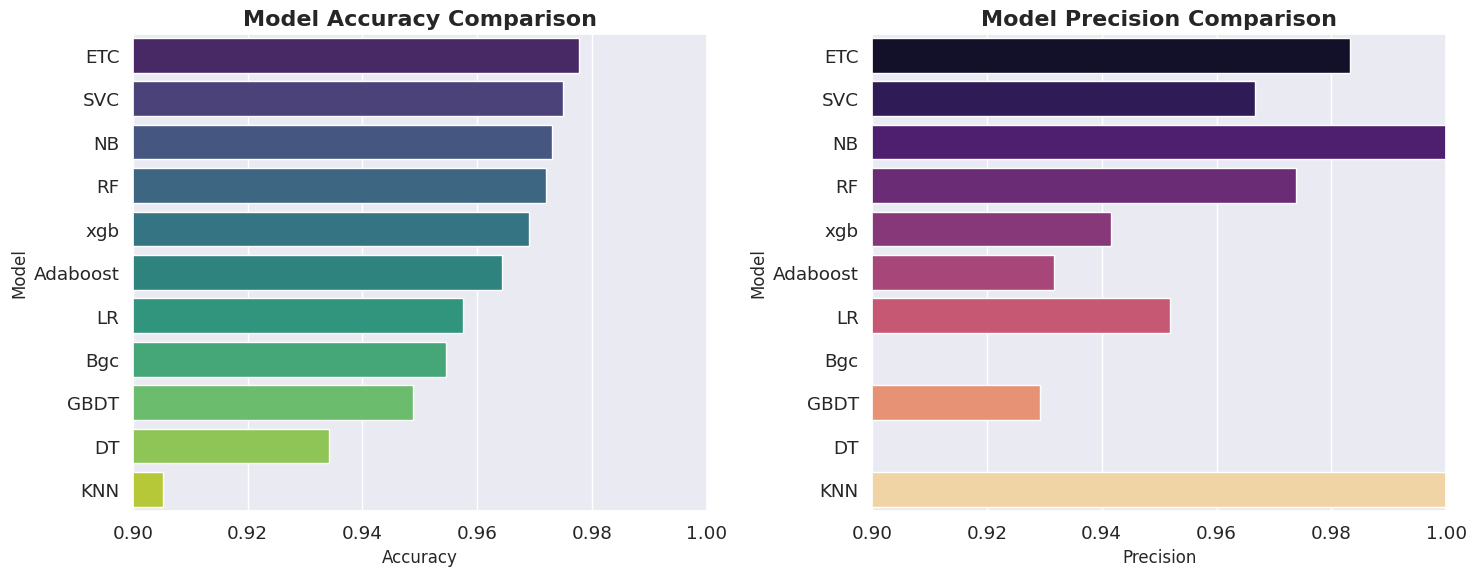


TOP 5 MODELS BY ACCURACY
Model  Accuracy  Precision
  ETC  0.977756   0.983193
  SVC  0.974855   0.966667
   NB  0.972921   1.000000
   RF  0.971954   0.973913
  xgb  0.969052   0.941667

Creating ensemble with: ETC, SVC, NB, RF, xgb

Training ensemble model...

ENSEMBLE MODEL PERFORMANCE
Accuracy:  0.9816
Precision: 1.0000

FINAL COMPARISON (Including Ensemble)
           Model  Accuracy  Precision
Ensemble (Top 5)  0.981625   1.000000
             ETC  0.977756   0.983193
             SVC  0.974855   0.966667
              NB  0.972921   1.000000
              RF  0.971954   0.973913
             xgb  0.969052   0.941667
        Adaboost  0.964217   0.931624
              LR  0.957447   0.951923
             Bgc  0.954545   0.852713
            GBDT  0.948743   0.929293
              DT  0.934236   0.850000
             KNN  0.905222   1.000000


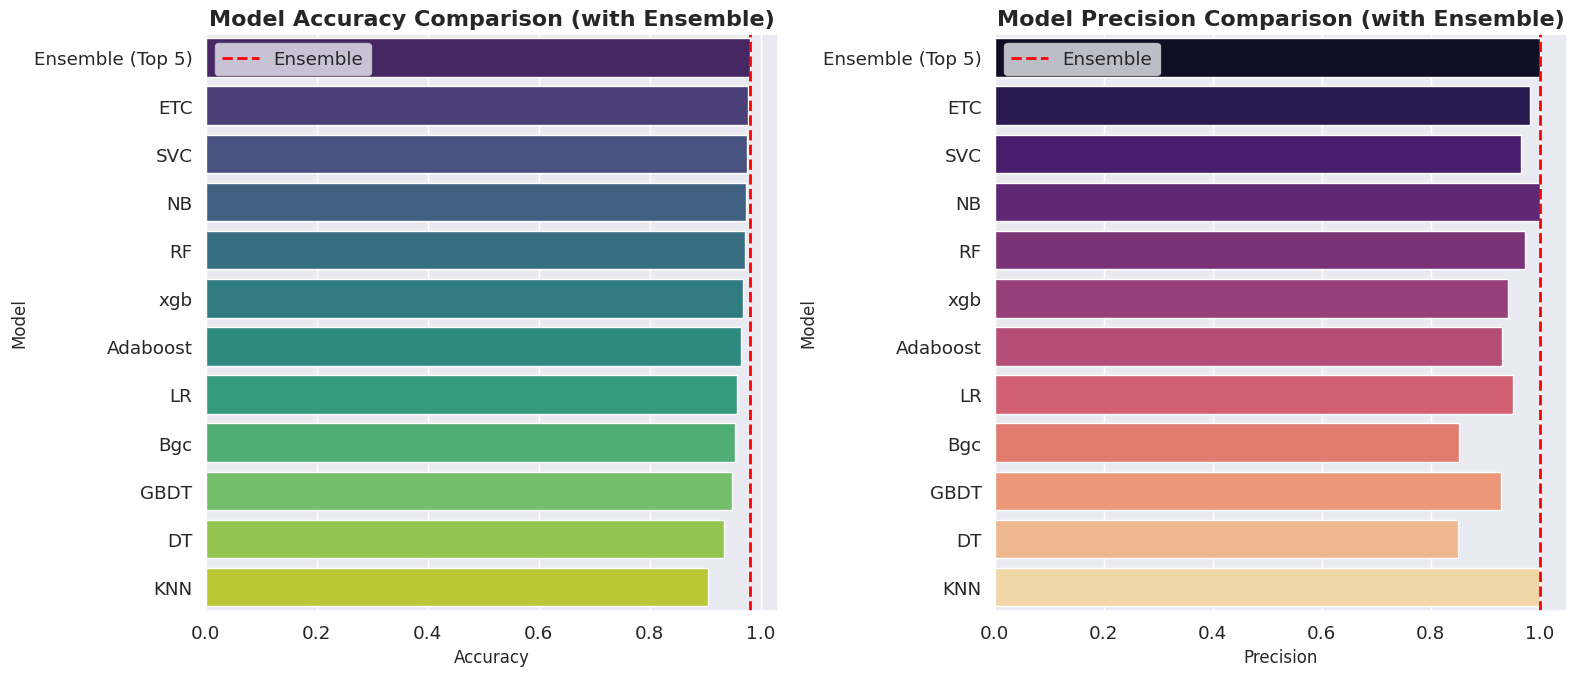

In [ ]:
# First, recreate the classifiers dictionary (it was overwritten in your previous loop)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Recreate all classifier instances
svc = SVC(kernel="sigmoid", gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

# Recreate the dictionary
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

# Train all classifiers and collect scores
accuracy_scores = []
precision_scores = []
model_names = []

# Use 'clf' instead of 'clfs' to avoid overwriting the dictionary
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    
    model_names.append(name)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

# Create a performance DataFrame for better visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

# Sort by accuracy to identify top 3 models
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)
print(performance_df.to_string(index=False))

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
sns.barplot(data=performance_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].set_xlim([0.9, 1.0])  # Adjust based on your scores

# Precision comparison
sns.barplot(data=performance_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].set_xlim([0.9, 1.0])  # Adjust based on your scores

plt.tight_layout()
plt.show()

# Display top 5 models
print("\n" + "="*50)
print("TOP 5 MODELS BY ACCURACY")
print("="*50)
print(performance_df.head(5).to_string(index=False))

# Create an ensemble of the top 5 models
from sklearn.ensemble import VotingClassifier

# Get the top 5 model names
top_5_models = performance_df.head(5)['Model'].tolist()
print("\n" + "="*50)
print(f"Creating ensemble with: {', '.join(top_5_models)}")
print("="*50)

# Recreate fresh instances of the top 5 models for the ensemble
top_5_classifiers = []
for model_name in top_5_models:
    if model_name == 'SVC':
        top_5_classifiers.append(('SVC', SVC(kernel="sigmoid", gamma=1.0, probability=True)))
    elif model_name == 'KNN':
        top_5_classifiers.append(('KNN', KNeighborsClassifier()))
    elif model_name == 'NB':
        top_5_classifiers.append(('NB', MultinomialNB()))
    elif model_name == 'DT':
        top_5_classifiers.append(('DT', DecisionTreeClassifier(max_depth=5)))
    elif model_name == 'LR':
        top_5_classifiers.append(('LR', LogisticRegression(solver='liblinear', penalty='l1')))
    elif model_name == 'RF':
        top_5_classifiers.append(('RF', RandomForestClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Adaboost':
        top_5_classifiers.append(('Adaboost', AdaBoostClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Bgc':
        top_5_classifiers.append(('Bgc', BaggingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'ETC':
        top_5_classifiers.append(('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'GBDT':
        top_5_classifiers.append(('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'xgb':
        top_5_classifiers.append(('xgb', XGBClassifier(n_estimators=50, random_state=2)))

# Create voting ensemble (soft voting for probability-based voting)
ensemble = VotingClassifier(estimators=top_5_classifiers, voting='soft')

# Train the ensemble
print("\nTraining ensemble model...")
ensemble.fit(X_train, y_train)

# Evaluate the ensemble
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)

print("\n" + "="*50)
print("ENSEMBLE MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")

# Compare ensemble with individual models
comparison_df = pd.DataFrame({
    'Model': model_names + ['Ensemble (Top 5)'],
    'Accuracy': accuracy_scores + [ensemble_accuracy],
    'Precision': precision_scores + [ensemble_precision]
})
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("FINAL COMPARISON (Including Ensemble)")
print("="*50)
print(comparison_df.to_string(index=False))

# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy comparison
sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].axvline(x=ensemble_accuracy, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[0].legend()

# Precision comparison
sns.barplot(data=comparison_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].axvline(x=ensemble_precision, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[1].legend()

plt.tight_layout()
plt.show()


Creating ensemble with: ETC, SVC, NB, RF, xgb, Adaboost, LR

Training ensemble model...

ENSEMBLE MODEL PERFORMANCE
Accuracy:  0.9778
Precision: 0.9832

FINAL COMPARISON (Including Ensemble)
           Model  Accuracy  Precision
             ETC  0.977756   0.983193
Ensemble (Top 7)  0.977756   0.983193
             SVC  0.974855   0.966667
              NB  0.972921   1.000000
              RF  0.971954   0.973913
             xgb  0.969052   0.941667
        Adaboost  0.964217   0.931624
              LR  0.957447   0.951923
             Bgc  0.954545   0.852713
            GBDT  0.948743   0.929293
              DT  0.932302   0.833333
             KNN  0.905222   1.000000


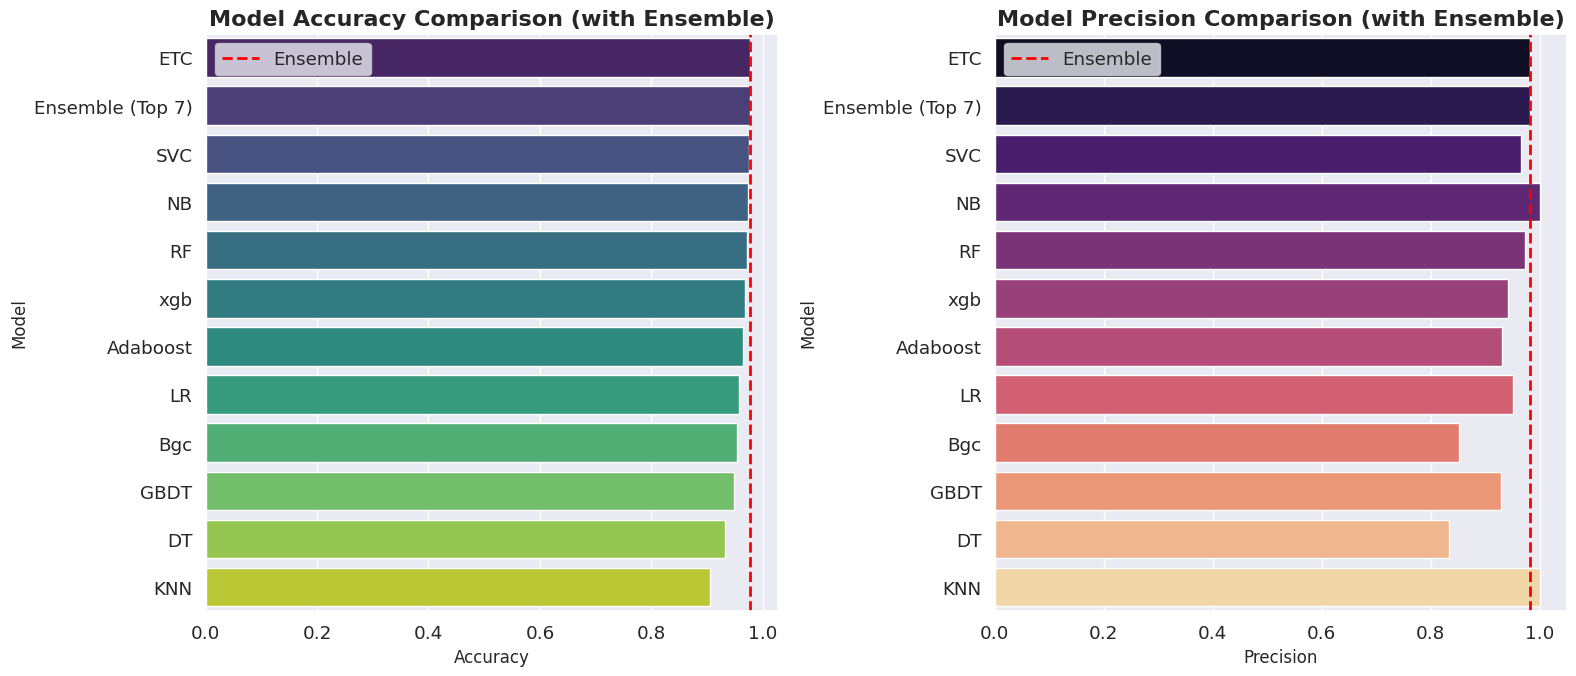

In [ ]:
# Create an ensemble of the top 7 models (instead of top 5 models)
from sklearn.ensemble import VotingClassifier

# Get the top 7 model names
top_7_models = performance_df.head(7)['Model'].tolist()  # Change to top 7 models
print("\n" + "="*50)
print(f"Creating ensemble with: {', '.join(top_7_models)}")
print("="*50)

# Recreate fresh instances of the top 7 models for the ensemble
top_7_classifiers = []
for model_name in top_7_models:
    if model_name == 'SVC':
        top_7_classifiers.append(('SVC', SVC(kernel="sigmoid", gamma=1.0, probability=True)))
    elif model_name == 'KNN':
        top_7_classifiers.append(('KNN', KNeighborsClassifier()))
    elif model_name == 'NB':
        top_7_classifiers.append(('NB', MultinomialNB()))
    elif model_name == 'DT':
        top_7_classifiers.append(('DT', DecisionTreeClassifier(max_depth=5)))
    elif model_name == 'LR':
        top_7_classifiers.append(('LR', LogisticRegression(solver='liblinear', penalty='l1')))
    elif model_name == 'RF':
        top_7_classifiers.append(('RF', RandomForestClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Adaboost':
        top_7_classifiers.append(('Adaboost', AdaBoostClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Bgc':
        top_7_classifiers.append(('Bgc', BaggingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'ETC':
        top_7_classifiers.append(('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'GBDT':
        top_7_classifiers.append(('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'xgb':
        top_7_classifiers.append(('xgb', XGBClassifier(n_estimators=50, random_state=2)))

# Create voting ensemble (soft voting for probability-based voting)
ensemble = VotingClassifier(estimators=top_7_classifiers, voting='soft')

# Train the ensemble
print("\nTraining ensemble model...")
ensemble.fit(X_train, y_train)

# Evaluate the ensemble
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)

print("\n" + "="*50)
print("ENSEMBLE MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")

# Compare ensemble with individual models
comparison_df = pd.DataFrame({
    'Model': model_names + ['Ensemble (Top 7)'],  # Include ensemble for top 7 models
    'Accuracy': accuracy_scores + [ensemble_accuracy],
    'Precision': precision_scores + [ensemble_precision]
})
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("FINAL COMPARISON (Including Ensemble)")
print("="*50)
print(comparison_df.to_string(index=False))

# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy comparison
sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].axvline(x=ensemble_accuracy, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[0].legend()

# Precision comparison
sns.barplot(data=comparison_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].axvline(x=ensemble_precision, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[1].legend()

plt.tight_layout()
plt.show()



Creating ensemble with: ETC, SVC, NB, RF, xgb, Adaboost

Training ensemble model...

ENSEMBLE MODEL PERFORMANCE
Accuracy:  0.9816
Precision: 1.0000

FINAL COMPARISON (Including Ensemble)
           Model  Accuracy  Precision
Ensemble (Top 6)  0.981625   1.000000
             ETC  0.977756   0.983193
             SVC  0.974855   0.966667
              NB  0.972921   1.000000
              RF  0.971954   0.973913
             xgb  0.969052   0.941667
        Adaboost  0.964217   0.931624
              LR  0.957447   0.951923
             Bgc  0.954545   0.852713
            GBDT  0.948743   0.929293
              DT  0.932302   0.833333
             KNN  0.905222   1.000000


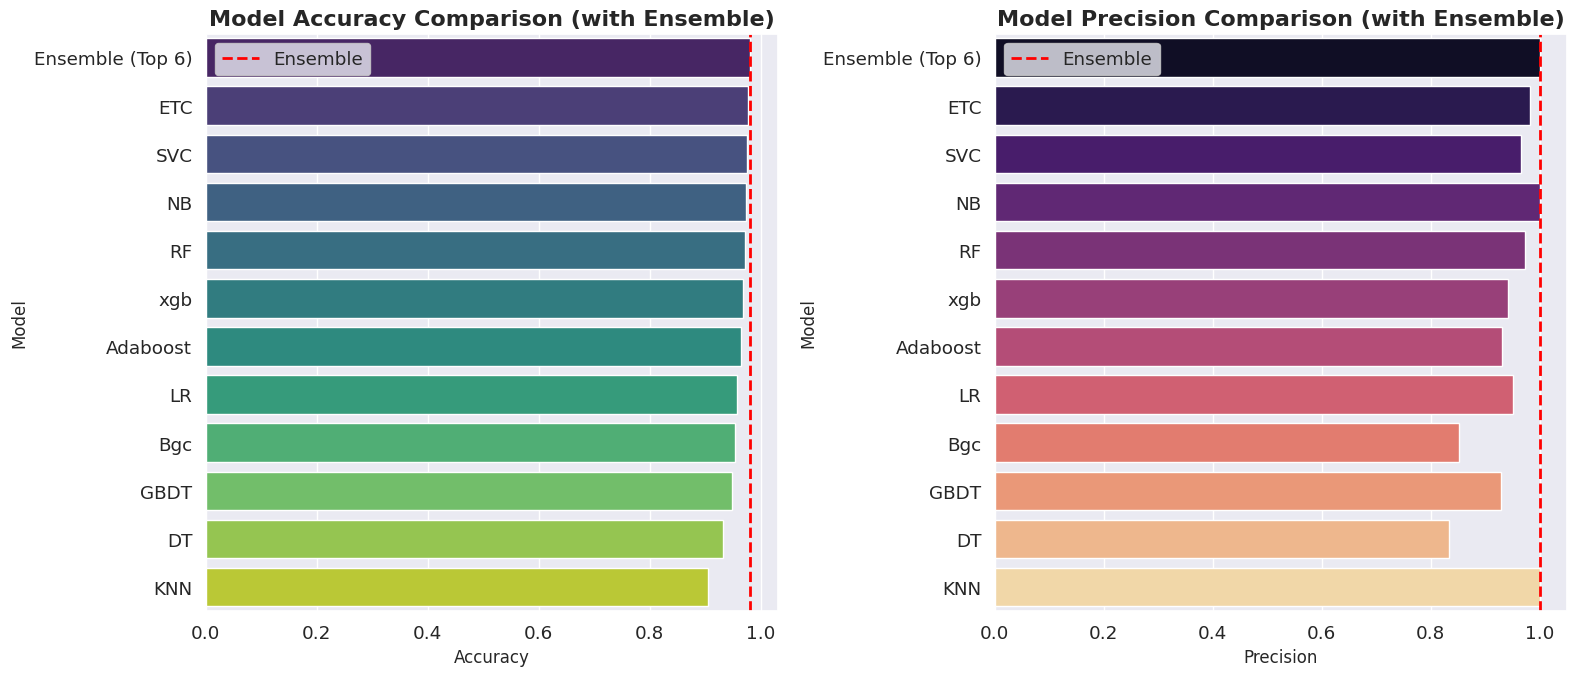

In [ ]:
# Create an ensemble of the top 6 models (instead of top 7 models)
from sklearn.ensemble import VotingClassifier

# Get the top 6 model names
top_6_models = performance_df.head(6)['Model'].tolist()  # Change to top 6 models
print("\n" + "="*50)
print(f"Creating ensemble with: {', '.join(top_6_models)}")
print("="*50)

# Recreate fresh instances of the top 6 models for the ensemble
top_6_classifiers = []
for model_name in top_6_models:
    if model_name == 'SVC':
        top_6_classifiers.append(('SVC', SVC(kernel="sigmoid", gamma=1.0, probability=True)))
    elif model_name == 'KNN':
        top_6_classifiers.append(('KNN', KNeighborsClassifier()))
    elif model_name == 'NB':
        top_6_classifiers.append(('NB', MultinomialNB()))
    elif model_name == 'DT':
        top_6_classifiers.append(('DT', DecisionTreeClassifier(max_depth=5)))
    elif model_name == 'LR':
        top_6_classifiers.append(('LR', LogisticRegression(solver='liblinear', penalty='l1')))
    elif model_name == 'RF':
        top_6_classifiers.append(('RF', RandomForestClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Adaboost':
        top_6_classifiers.append(('Adaboost', AdaBoostClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'Bgc':
        top_6_classifiers.append(('Bgc', BaggingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'ETC':
        top_6_classifiers.append(('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'GBDT':
        top_6_classifiers.append(('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)))
    elif model_name == 'xgb':
        top_6_classifiers.append(('xgb', XGBClassifier(n_estimators=50, random_state=2)))

# Create voting ensemble (soft voting for probability-based voting)
ensemble = VotingClassifier(estimators=top_6_classifiers, voting='soft')

# Train the ensemble
print("\nTraining ensemble model...")
ensemble.fit(X_train, y_train)

# Evaluate the ensemble
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)

print("\n" + "="*50)
print("ENSEMBLE MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")

# Compare ensemble with individual models
comparison_df = pd.DataFrame({
    'Model': model_names + ['Ensemble (Top 6)'],  # Include ensemble for top 6 models
    'Accuracy': accuracy_scores + [ensemble_accuracy],
    'Precision': precision_scores + [ensemble_precision]
})
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("FINAL COMPARISON (Including Ensemble)")
print("="*50)
print(comparison_df.to_string(index=False))

# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Accuracy comparison
sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].axvline(x=ensemble_accuracy, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[0].legend()

# Precision comparison
sns.barplot(data=comparison_df, x='Precision', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Model Precision Comparison (with Ensemble)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].axvline(x=ensemble_precision, color='red', linestyle='--', linewidth=2, label='Ensemble')
axes[1].legend()

plt.tight_layout()
plt.show()
